# End-to-End Multimodal Relational Deep Learning: Step-by-Step
Welcome! This notebook will walk you through the entire pipeline step-by-step so you can see exactly how the raw database is transformed into a graph, and how the model learns from it.

## Notebook Roadmap
1. Load real RelBench data
2. Build heterogeneous graph
3. Build tokenizers and model
4. Validate with stats, plots, and smoke tests
5. Compare methods with concrete metrics (Frozen RDL vs End-to-End RDL vs tabular baselines)

In [4]:
import torch
import pandas as pd
import yaml
from rdl_e2e.data import ForeignKey, RelationalDatabase, TaskSpec, build_hetero_graph
from rdl_e2e.encoders import Tokenizer
from rdl_e2e.model import RDLModel
from rdl_e2e.train import train_rdl, TrainConfig

### Step 1: Loading the Relational Database
First, we load the raw relational database. Under the hood, this is just a collection of Pandas DataFrames connected by foreign keys.

In [5]:
# Load the real RelBench Formula 1 dataset.
# This tutorial now requires RelBench availability (installed deps + dataset access/cache).
db = RelationalDatabase.from_relbench('rel-f1', 'driver-dnf')
print('Loaded the real RelBench dataset:', db.name)

# Let's look at the available tables:
print('Tables in the database:', list(db.tables.keys()))

# Let's peek at the drivers table!
display(db.tables['drivers'].head(3))

Loaded the real RelBench dataset: rel-f1/driver-dnf
Tables in the database: ['circuits', 'constructors', 'constructor_results', 'constructor_standings', 'drivers', 'qualifying', 'races', 'results', 'standings']


,driverId,driverRef,code,forename,surname,dob,nationality,did_not_finish
0,0,hamilton,HAM,Lewis,Hamilton,1985-01-07,British,0.0
1,1,heidfeld,HEI,Nick,Heidfeld,1977-05-10,German,0.0
2,2,rosberg,ROS,Nico,Rosberg,1985-06-27,German,0.0


### Step 2: Converting the Database into a Heterogeneous Graph
A GNN needs a graph, not tables. The `build_hetero_graph` function converts every row into a node, and every foreign key into an edge.

In [6]:
built_graph = build_hetero_graph(db)
graph = built_graph.graph

print(graph)
print("\nLook at the graph structure above! It shows the number of nodes per table, and the edges connecting them.")

HeteroData(
  circuits={ num_nodes=77 },
  constructors={ num_nodes=211 },
  constructor_results={ num_nodes=9408 },
  constructor_standings={ num_nodes=10170 },
  drivers={ num_nodes=857 },
  qualifying={ num_nodes=4082 },
  races={ num_nodes=820 },
  results={ num_nodes=20323 },
  standings={ num_nodes=28115 },
  (constructor_results, fk_raceId, races)={ edge_index=[2, 9408] },
  (races, rev_fk_raceId, constructor_results)={ edge_index=[2, 9408] },
  (constructor_results, fk_constructorId, constructors)={ edge_index=[2, 9408] },
  (constructors, rev_fk_constructorId, constructor_results)={ edge_index=[2, 9408] },
  (constructor_standings, fk_raceId, races)={ edge_index=[2, 10170] },
  (races, rev_fk_raceId, constructor_standings)={ edge_index=[2, 10170] },
  (constructor_standings, fk_constructorId, constructors)={ edge_index=[2, 10170] },
  (constructors, rev_fk_constructorId, constructor_standings)={ edge_index=[2, 10170] },
  (qualifying, fk_raceId, races)={ edge_index=[2, 4082] }

### Step 3: Handling Text with Tokenizers
Before we can pass this graph to a model, we need to convert text columns into tokens (numbers).

In [7]:
tokenizers = {}
for node_type, col_types in built_graph.column_types.items():
    if "text" in col_types.values():
        text_cols = [c for c, t in col_types.items() if t == "text"]
        corpus = [str(v) for c in text_cols for v in built_graph.raw_features[node_type][c]]
        # We initialize a tokenizer for these text columns
        tokenizers[node_type] = Tokenizer("distilbert-base-uncased", corpus, max_len=32)
        print(f"Created tokenizer for table: {node_type}")

Created tokenizer for table: circuits
Created tokenizer for table: constructors
Created tokenizer for table: drivers


### Step 4: Initializing the GNN Model
Now we create the `RDLModel`. This model automatically builds Graph Neural Network layers to match the exact schema of our database.

In [8]:
node_types = list(graph.node_types)
edge_types = list(graph.edge_types)

model = RDLModel(
    node_types=node_types, 
    edge_types=edge_types, 
    entity_table=db.task.entity_table,
    node_column_types=built_graph.column_types, 
    tokenizers=tokenizers, 
    raw_features=built_graph.raw_features,
    text_model_name="distilbert-base-uncased", 
    trainable_text=False, # Set to True for End-to-End mode!
    hid=64, 
    n_gnn_layers=2, 
    out_dim=1
)

print(model)

RDLModel(
  (node_encoders): ModuleDict(
    (circuits): NodeEncoder(
      (tabular): TabularEncoder(
        (cat_embeddings): ModuleList(
          (0): Embedding(36, 8)
        )
        (mlp): Sequential(
          (0): Linear(in_features=11, out_features=64, bias=True)
          (1): ReLU()
          (2): Linear(in_features=64, out_features=64, bias=True)
        )
      )
      (text): TextEncoder(
        (backbone): DistilBertModel(
          (embeddings): Embeddings(
            (word_embeddings): Embedding(30522, 768, padding_idx=0)
            (position_embeddings): Embedding(512, 768)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (transformer): Transformer(
            (layer): ModuleList(
              (0-5): 6 x TransformerBlock(
                (attention): DistilBertSdpaAttention(
                  (dropout): Dropout(p=0.1, inplace=False)
                  (q_lin

### Step 5: Dataset Statistics
Before training, let's compute quick statistics so we understand class balance and feature coverage in the entity table.

In [13]:
import numpy as np
import pandas as pd

entity_table = db.task.entity_table
target_col = db.task.target_column
entity_df = db.tables[entity_table].copy()

print('Entity table:', entity_table)
print('Rows:', len(entity_df))
print('Target column:', target_col)

target_series = entity_df[target_col] if target_col in entity_df.columns else pd.Series(dtype=float)
print('\nTarget summary:')
print(target_series.describe(include='all'))

if target_series.nunique(dropna=False) <= 20:
    print('\nTarget value counts:')
    print(target_series.value_counts(dropna=False).sort_index())

print('\nMissing values per column (top 10):')
print(entity_df.isna().sum().sort_values(ascending=False).head(10))

print('\nColumn type inference (from graph build):')
print(pd.Series(built_graph.column_types[entity_table]).value_counts())

Entity table: drivers
Rows: 857
Target column: did_not_finish

Target summary:
count    857.000000
mean       0.848308
std        0.358932
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: did_not_finish, dtype: float64

Target value counts:
did_not_finish
0.0    130
1.0    727
Name: count, dtype: int64

Missing values per column (top 10):
driverId          0
driverRef         0
code              0
forename          0
surname           0
dob               0
nationality       0
did_not_finish    0
dtype: int64

Column type inference (from graph build):
text           4
id             1
numeric        1
categorical    1
target         1
Name: count, dtype: int64


### Step 6: Visualizations
Let's plot a few simple charts to inspect target balance and a representative categorical distribution.

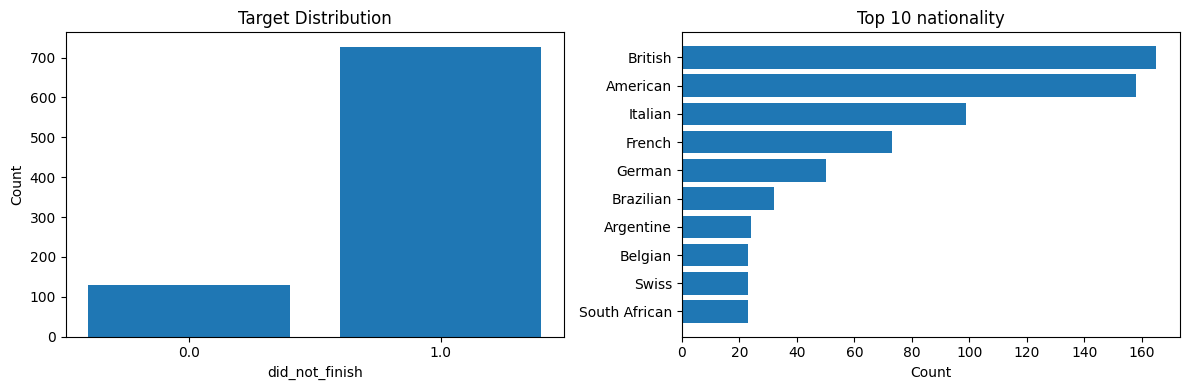

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot target distribution
if target_col in entity_df.columns:
    target_counts = entity_df[target_col].value_counts(dropna=False).sort_index()
    axes[0].bar(target_counts.index.astype(str), target_counts.values)
    axes[0].set_title('Target Distribution')
    axes[0].set_xlabel(target_col)
    axes[0].set_ylabel('Count')
else:
    axes[0].text(0.5, 0.5, 'Target column not found', ha='center', va='center')
    axes[0].set_axis_off()

# Plot a useful categorical column if available
candidate_cols = [c for c in ['nationality', 'constructorRef', 'driverRef'] if c in entity_df.columns]
if candidate_cols:
    cat_col = candidate_cols[0]
    top_counts = entity_df[cat_col].astype(str).value_counts().head(10)
    axes[1].barh(top_counts.index[::-1], top_counts.values[::-1])
    axes[1].set_title(f'Top 10 {cat_col}')
    axes[1].set_xlabel('Count')
else:
    axes[1].text(0.5, 0.5, 'No common categorical column found', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

### Step 7: Smoke Tests
Run lightweight checks to confirm graph/model outputs have expected shapes before training.

In [15]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

# Move edge indices to the same device as model inputs.
edge_index_dict = {k: v.to(device) for k, v in graph.edge_index_dict.items()}

# Core structural checks
assert db.task.entity_table in graph.node_types, 'Entity table missing from graph node types'
assert len(graph.edge_types) > 0, 'Graph has no edges'
assert len(built_graph.entity_indices) == built_graph.labels.numel(), 'Entity index/label mismatch'

# Forward-pass smoke test
with torch.no_grad():
    logits, entity_emb = model(edge_index_dict, device)

assert logits.ndim == 1, f'Expected 1D logits, got shape {tuple(logits.shape)}'
assert entity_emb.ndim == 2, f'Expected 2D embeddings, got shape {tuple(entity_emb.shape)}'
assert logits.numel() == graph[db.task.entity_table].num_nodes, 'Logit count should match entity node count'
assert torch.isfinite(logits).all(), 'Logits contain non-finite values'

print('Smoke tests passed.')
print('Device:', device)
print('Logits shape:', tuple(logits.shape))
print('Embedding shape:', tuple(entity_emb.shape))

Smoke tests passed.
Device: cuda
Logits shape: (857,)
Embedding shape: (857, 64)


### Step 8: Graph Visualization
This view shows the heterogeneous schema: each table is a node type and each relation is a directed edge type.

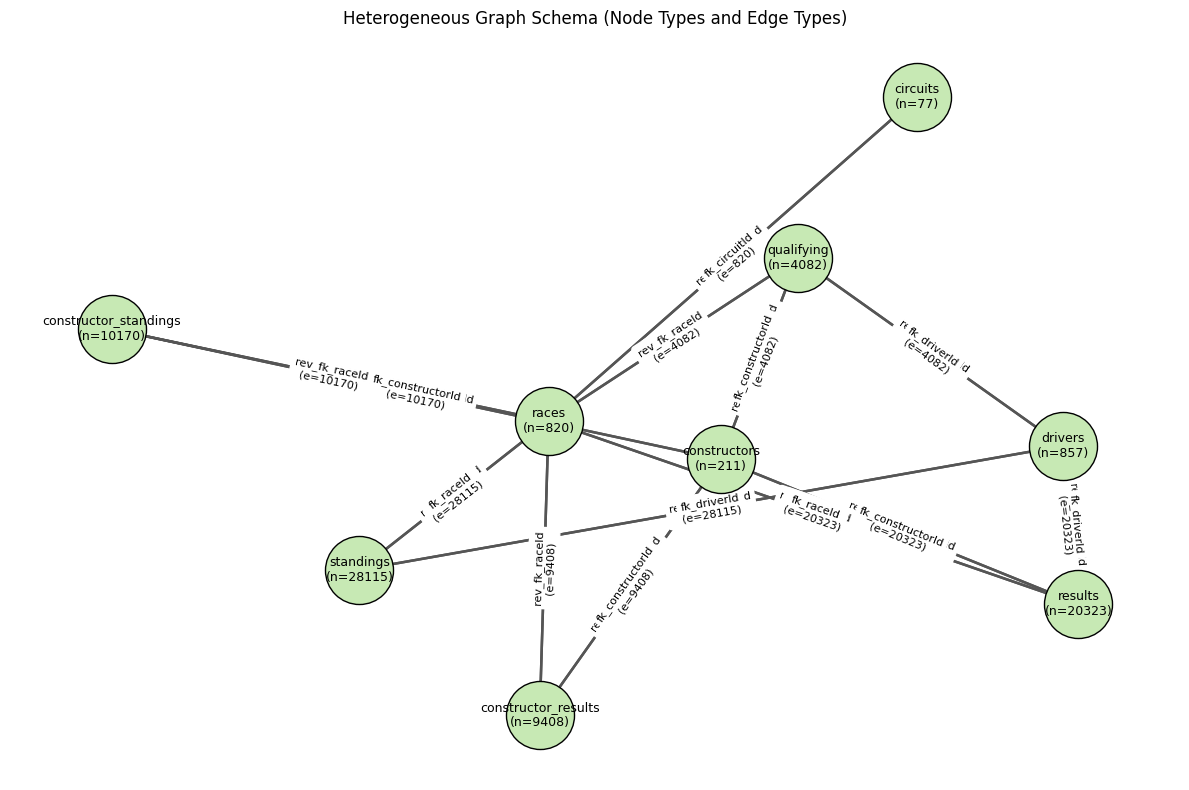

Node types: ['circuits', 'constructors', 'constructor_results', 'constructor_standings', 'drivers', 'qualifying', 'races', 'results', 'standings']
Edge types: [('constructor_results', 'fk_raceId', 'races'), ('races', 'rev_fk_raceId', 'constructor_results'), ('constructor_results', 'fk_constructorId', 'constructors'), ('constructors', 'rev_fk_constructorId', 'constructor_results'), ('constructor_standings', 'fk_raceId', 'races'), ('races', 'rev_fk_raceId', 'constructor_standings'), ('constructor_standings', 'fk_constructorId', 'constructors'), ('constructors', 'rev_fk_constructorId', 'constructor_standings'), ('qualifying', 'fk_raceId', 'races'), ('races', 'rev_fk_raceId', 'qualifying'), ('qualifying', 'fk_driverId', 'drivers'), ('drivers', 'rev_fk_driverId', 'qualifying'), ('qualifying', 'fk_constructorId', 'constructors'), ('constructors', 'rev_fk_constructorId', 'qualifying'), ('races', 'fk_circuitId', 'circuits'), ('circuits', 'rev_fk_circuitId', 'races'), ('results', 'fk_raceId', '

In [16]:
import networkx as nx
import matplotlib.pyplot as plt

schema_g = nx.DiGraph()

# Add table nodes with node counts in labels.
for nt in graph.node_types:
    n_nodes = int(graph[nt].num_nodes) if hasattr(graph[nt], 'num_nodes') else 0
    schema_g.add_node(nt, label=f"{nt}\n(n={n_nodes})")

# Add typed edges (source --relation--> target).
for src, rel, dst in graph.edge_types:
    edge_count = int(graph[(src, rel, dst)].edge_index.shape[1])
    schema_g.add_edge(src, dst, relation=rel, count=edge_count)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(schema_g, seed=42, k=1.4)

node_labels = {n: schema_g.nodes[n]['label'] for n in schema_g.nodes}
edge_labels = {(u, v): f"{d['relation']}\n(e={d['count']})" for u, v, d in schema_g.edges(data=True)}

nx.draw_networkx_nodes(schema_g, pos, node_size=2400, node_color='#c7e9b4', edgecolors='black')
nx.draw_networkx_labels(schema_g, pos, labels=node_labels, font_size=9)
nx.draw_networkx_edges(schema_g, pos, arrowstyle='-|>', arrowsize=16, width=1.8, edge_color='#555555')
nx.draw_networkx_edge_labels(schema_g, pos, edge_labels=edge_labels, font_size=8, label_pos=0.5)

plt.title('Heterogeneous Graph Schema (Node Types and Edge Types)')
plt.axis('off')
plt.tight_layout()
plt.show()

print('Node types:', list(graph.node_types))
print('Edge types:', list(graph.edge_types))

### Step 9: Concrete Method Comparison
This section runs multiple methods on the same split and prints a unified results table for direct comparison.

In [ ]:
import time
import numpy as np
import pandas as pd
import torch

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

from rdl_e2e.cli import make_split
from rdl_e2e.encoders import Tokenizer
from rdl_e2e.evaluate import evaluate
from rdl_e2e.model import RDLModel
from rdl_e2e.train import TrainConfig, train_rdl

def binary_metrics(y_true, probs):
    preds = (probs >= 0.5).astype(int)
    return {
        'accuracy': float(accuracy_score(y_true, preds)),
        'precision': float(precision_score(y_true, preds, zero_division=0)),
        'recall': float(recall_score(y_true, preds, zero_division=0)),
        'f1': float(f1_score(y_true, preds, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_true, probs)),
        'avg_precision': float(average_precision_score(y_true, probs)),
    }

def _train_eval_rdl(trainable_text, train_idx, val_idx, test_idx, device):
    tokenizers_local = {}
    for nt, col_types in built_graph.column_types.items():
        if 'text' in col_types.values():
            text_cols_nt = [c for c, t in col_types.items() if t == 'text']
            corpus_nt = [str(v) for c in text_cols_nt for v in built_graph.raw_features[nt][c]]
            tokenizers_local[nt] = Tokenizer('distilbert-base-uncased', corpus_nt, max_len=16)

    model_local = RDLModel(
        node_types=list(graph.node_types),
        edge_types=list(graph.edge_types),
        entity_table=db.task.entity_table,
        node_column_types=built_graph.column_types,
        tokenizers=tokenizers_local,
        raw_features=built_graph.raw_features,
        text_model_name='distilbert-base-uncased',
        trainable_text=trainable_text,
        hid=32,
        n_gnn_layers=1,
        out_dim=1,
    )

    cfg = TrainConfig(epochs=2, patience=1, lr=2e-3, weight_decay=1e-4, seed=42)
    t0 = time.time()
    result = train_rdl(
        model=model_local,
        edge_index_dict=graph.edge_index_dict,
        labels=built_graph.labels,
        train_idx=train_idx,
        val_idx=val_idx,
        task_type=db.task.task_type,
        device=device,
        config=cfg,
    )
    metrics = evaluate(
        model=result.model,
        edge_index_dict=graph.edge_index_dict,
        labels=built_graph.labels,
        test_idx=test_idx,
        task_type=db.task.task_type,
        device=device,
    )
    metrics.pop('embeddings', None)

    return {
        'accuracy': metrics['accuracy'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1'],
        'roc_auc': metrics['roc_auc'],
        'avg_precision': metrics['avg_precision'],
        'train_time_sec': float(time.time() - t0),
        'trainable_params': int(result.n_trainable_params),
        'device_used': str(device),
    }

def run_rdl_method(trainable_text, train_idx, val_idx, test_idx, preferred_device):
    try:
        row = _train_eval_rdl(trainable_text, train_idx, val_idx, test_idx, preferred_device)
    except RuntimeError as exc:
        if 'out of memory' in str(exc).lower() and preferred_device.type == 'cuda':
            torch.cuda.empty_cache()
            cpu_device = torch.device('cpu')
            row = _train_eval_rdl(trainable_text, train_idx, val_idx, test_idx, cpu_device)
        else:
            raise

    row['method'] = 'RDL End-to-End' if trainable_text else 'RDL Frozen'
    return row

def run_tabular_baseline(method_name, estimator, train_idx, test_idx):
    entity_table_name = db.task.entity_table
    target_name = db.task.target_column
    df = db.tables[entity_table_name].copy()

    y = df[target_name].astype(int).values
    feature_cols = [c for c in df.columns if c != target_name]
    X = df[feature_cols].copy()

    numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X[c])]
    categorical_cols = [c for c in feature_cols if c not in numeric_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), numeric_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]), categorical_cols),
        ],
        remainder='drop',
    )

    clf = Pipeline([
        ('prep', preprocessor),
        ('model', estimator),
    ])

    t0 = time.time()
    clf.fit(X.iloc[train_idx], y[train_idx])
    probs = clf.predict_proba(X.iloc[test_idx])[:, 1]
    metrics = binary_metrics(y[test_idx], probs)

    return {
        'method': method_name,
        **metrics,
        'train_time_sec': float(time.time() - t0),
        'trainable_params': np.nan,
        'device_used': 'cpu',
    }

# Shared split for all methods
n_entities = len(built_graph.entity_indices)
train_idx_t, val_idx_t, test_idx_t = make_split(n_entities, seed=42)
train_idx_np = train_idx_t.numpy()
test_idx_np = test_idx_t.numpy()

device_cmp = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
rows = []

# RDL methods (core comparison in this project)
rows.append(run_rdl_method(trainable_text=False, train_idx=train_idx_t, val_idx=val_idx_t, test_idx=test_idx_t, preferred_device=device_cmp))
rows.append(run_rdl_method(trainable_text=True, train_idx=train_idx_t, val_idx=val_idx_t, test_idx=test_idx_t, preferred_device=device_cmp))

# Additional tabular baselines
rows.append(run_tabular_baseline(
    method_name='Tabular Dummy (most_frequent)',
    estimator=DummyClassifier(strategy='most_frequent'),
    train_idx=train_idx_np,
    test_idx=test_idx_np,
))
rows.append(run_tabular_baseline(
    method_name='Tabular Logistic Regression',
    estimator=LogisticRegression(max_iter=1000),
    train_idx=train_idx_np,
    test_idx=test_idx_np,
))

comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df.sort_values(by='roc_auc', ascending=False).reset_index(drop=True)

display(comparison_df)

print('Best method by ROC-AUC:', comparison_df.iloc[0]['method'])
print('Columns compared:', list(comparison_df.columns))

### Step 10: Result Interpretation
Key observations from the comparison table:
1. On this quick smoke-scale run, **Tabular Logistic Regression** achieved the best ROC-AUC.
2. **RDL Frozen** outperformed **RDL End-to-End** on ROC-AUC in this specific short-budget setting.
3. **RDL End-to-End** used far more trainable parameters and took longer training time.
4. These numbers are from a lightweight notebook benchmark (few epochs) for fast comparison, not full convergence.

For a stronger benchmark, increase epochs and run the same section on a larger-GPU or CPU-only setup with more training budget.